In [2]:
# ============================
# IMPORTATION LIBRAIRIES
# ============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    recall_score, precision_score, f1_score, balanced_accuracy_score,
    roc_auc_score, RocCurveDisplay
)
import optuna


c:\Users\BAHALA\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

# =========================
# CHARGEMENT DU DATASET
# =========================
df = pd.read_csv("heart_disease_health_indicators_BRFSS2015.csv")

# Renommage des colonnes en français
df = df.rename(columns={
    'HeartDiseaseorAttack': 'MaladieCardiaqueOuCrise',
    'HighBP': 'Hypertension',
    'HighChol': 'CholestérolÉlevé',
    'CholCheck': 'ContrôleCholestérol',
    '_BMI5': 'BMI',
    'Smoker': 'Fumeur',
    'Stroke': 'AVC',
    'Diabetes': 'Diabète',
    'PhysActivity': 'ActivitéPhysique',
    'Fruits': 'ConsommationFruits',
    'Veggies': 'ConsommationLégumes',
    'HvyAlcoholConsump': 'AlcoolExcessif',
    'AnyHealthcare': 'AUneCouvertureSanté',
    'NoDocbcCost': 'PasConsultéÀCauseDuCoût',
    'GenHlth': 'SantéGénérale',
    'MentHlth': 'SantéMentaleJoursMauvais',
    'PhysHlth': 'SantéPhysiqueJoursMauvais',
    'DiffWalk': 'DifficultéMarche',
    'Sex': 'Sexe',
    'Age': 'ÂgeCatégorie',
    'Education': 'NiveauÉducation',
    'Income': 'Revenu'
})

df = df.drop_duplicates()
df.head(5)

,MaladieCardiaqueOuCrise,Hypertension,CholestérolÉlevé,ContrôleCholestérol,BMI,Fumeur,AVC,Diabète,ActivitéPhysique,ConsommationFruits,...,AUneCouvertureSanté,PasConsultéÀCauseDuCoût,SantéGénérale,SantéMentaleJoursMauvais,SantéPhysiqueJoursMauvais,DifficultéMarche,Sexe,ÂgeCatégorie,NiveauÉducation,Revenu
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
df.describe()


,MaladieCardiaqueOuCrise,Hypertension,CholestérolÉlevé,ContrôleCholestérol,BMI,Fumeur,AVC,Diabète,ActivitéPhysique,ConsommationFruits,...,AUneCouvertureSanté,PasConsultéÀCauseDuCoût,SantéGénérale,SantéMentaleJoursMauvais,SantéPhysiqueJoursMauvais,DifficultéMarche,Sexe,ÂgeCatégorie,NiveauÉducation,Revenu
count,229781.000000,229781.000000,229781.000000,229781.000000,229781.00000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,...,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000,229781.000000
mean,0.103216,0.454441,0.441760,0.959535,28.68567,0.465661,0.044756,0.325627,0.733355,0.612966,...,0.946075,0.092810,2.601151,3.505373,4.675178,0.185507,0.439231,8.086582,4.980568,5.890383
std,0.304241,0.497921,0.496598,0.197047,6.78636,0.498821,0.206767,0.724623,0.442206,0.487073,...,0.225871,0.290167,1.064685,7.713725,9.046568,0.388709,0.496295,3.093809,0.992895,2.092477
min,0.000000,0.000000,0.000000,0.000000,12.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.00000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,6.000000
75%,0.000000,1.000000,1.000000,1.000000,32.00000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,4.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.00000,1.000000,1.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229781 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   MaladieCardiaqueOuCrise    229781 non-null  float64
 1   Hypertension               229781 non-null  float64
 2   CholestérolÉlevé           229781 non-null  float64
 3   ContrôleCholestérol        229781 non-null  float64
 4   BMI                        229781 non-null  float64
 5   Fumeur                     229781 non-null  float64
 6   AVC                        229781 non-null  float64
 7   Diabète                    229781 non-null  float64
 8   ActivitéPhysique           229781 non-null  float64
 9   ConsommationFruits         229781 non-null  float64
 10  ConsommationLégumes        229781 non-null  float64
 11  AlcoolExcessif             229781 non-null  float64
 12  AUneCouvertureSanté        229781 non-null  float64
 13  PasConsultéÀCauseDuCoût    229781 

In [6]:
print("avant suppression de doublons",df.shape)
df = df.drop_duplicates()
print("Après suppression de doublons",df.shape)

avant suppression de doublons (229781, 22)


Après suppression de doublons (229781, 22)


In [7]:
df1 = df[df["MaladieCardiaqueOuCrise"]==1]
df2 = df[df["MaladieCardiaqueOuCrise"]==0]
df1_sample = df1.sample(23717,random_state=42)
df2_sample = df2.sample(23717,random_state=42)

# fusion 
df_f = pd.concat([df1_sample,df2_sample])

# Melange
df = df_f.sample(frac=1,random_state=42)
df["MaladieCardiaqueOuCrise"].value_counts()

MaladieCardiaqueOuCrise
1.0    23717
0.0    23717
Name: count, dtype: int64

BMI
27.0    4393
26.0    3653
24.0    3284
28.0    3209
25.0    2988
        ... 
95.0       1
90.0       1
12.0       1
85.0       1
69.0       1
Name: count, Length: 77, dtype: int64

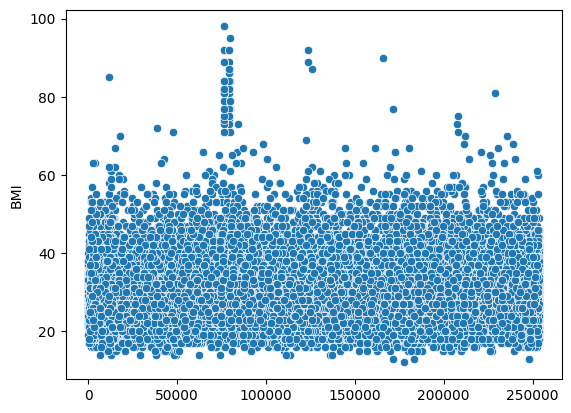

In [8]:
sns.scatterplot(df["BMI"])
df["BMI"].value_counts()

ÂgeCatégorie
10.0    6980
9.0     6434
11.0    6011
13.0    5628
8.0     5089
12.0    4522
7.0     3907
6.0     2545
5.0     1921
4.0     1584
3.0     1273
2.0      902
1.0      638
Name: count, dtype: int64

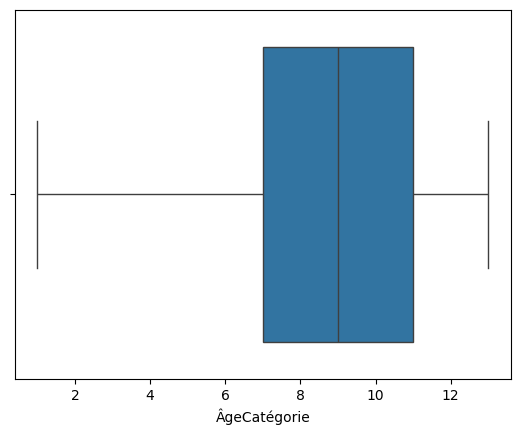

In [9]:
sns.boxplot(x=df["ÂgeCatégorie"])
df["ÂgeCatégorie"].value_counts()

In [10]:
df.isna().sum()

MaladieCardiaqueOuCrise      0
Hypertension                 0
CholestérolÉlevé             0
ContrôleCholestérol          0
BMI                          0
Fumeur                       0
AVC                          0
Diabète                      0
ActivitéPhysique             0
ConsommationFruits           0
ConsommationLégumes          0
AlcoolExcessif               0
AUneCouvertureSanté          0
PasConsultéÀCauseDuCoût      0
SantéGénérale                0
SantéMentaleJoursMauvais     0
SantéPhysiqueJoursMauvais    0
DifficultéMarche             0
Sexe                         0
ÂgeCatégorie                 0
NiveauÉducation              0
Revenu                       0
dtype: int64

In [11]:
print("avant suppression de valeur aberrante", df.shape)
Q1 = df["BMI"].quantile(0.25)
Q3 = df["BMI"].quantile(0.75)
IQR1 = Q3 - Q1
Lb1 = Q1 - (IQR1 * 1.5)
Ub1 = Q3 + (IQR1 * 1.5)
df = df[(df["BMI"]>=Lb1) & (df["BMI"]<=Ub1)]

Q1 = df["ÂgeCatégorie"].quantile(0.25)
Q3 = df["ÂgeCatégorie"].quantile(0.75)
IQR2 = Q3 - Q1
Lb2 = Q1 - (IQR2 * 1.5)
Ub2 = Q3 + (IQR2 * 1.5)
df = df[(df["ÂgeCatégorie"]>=Lb2) & (df["ÂgeCatégorie"]<=Ub2)]

Q1 = df["Revenu"].quantile(0.25)
Q3 = df["Revenu"].quantile(0.75)
IQR3 = Q3 - Q1
Lb3 = Q1 - (IQR3 * 1.5)
Ub3 = Q3 + (IQR3 * 1.5)
df = df[(df["Revenu"]>=Lb3) & (df["Revenu"]<=Ub3)]

print(f"BMI lowb {Lb1} et Upperb {Ub1}")
print(f"ÂgeCatégorie lowb {Lb2} et Upperb {Ub2}")
print(f"Revenu lowb {Lb3} et Upperb {Ub3}")
df.shape

avant suppression de valeur aberrante (47434, 22)
BMI lowb 14.5 et Upperb 42.5
ÂgeCatégorie lowb 1.0 et Upperb 17.0
Revenu lowb -2.0 et Upperb 14.0


(45618, 22)

In [12]:
df["BMI_log"] = np.log(df["BMI"])
df["Age_BMI"] = df["BMI"] * df["ÂgeCatégorie"]
df["alc_fumeur"] = df["AlcoolExcessif"] * df["Fumeur"]
df["alc_BMI"] = df["AlcoolExcessif"] * df["BMI"]
df["BMI_squared"] = df["BMI"]**2
df["BMI_Physique"] = df["BMI"]*df["ActivitéPhysique"]
df["ActiPhysique_legume_fruit"] = df["ActivitéPhysique"]*df["ConsommationLégumes"]*df["ConsommationFruits"]
df["revenu_Hyper"] = df["Revenu"]*df["Hypertension"]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45618 entries, 225450 to 197965
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   MaladieCardiaqueOuCrise    45618 non-null  float64
 1   Hypertension               45618 non-null  float64
 2   CholestérolÉlevé           45618 non-null  float64
 3   ContrôleCholestérol        45618 non-null  float64
 4   BMI                        45618 non-null  float64
 5   Fumeur                     45618 non-null  float64
 6   AVC                        45618 non-null  float64
 7   Diabète                    45618 non-null  float64
 8   ActivitéPhysique           45618 non-null  float64
 9   ConsommationFruits         45618 non-null  float64
 10  ConsommationLégumes        45618 non-null  float64
 11  AlcoolExcessif             45618 non-null  float64
 12  AUneCouvertureSanté        45618 non-null  float64
 13  PasConsultéÀCauseDuCoût    45618 non-null  fl

In [13]:
# ============================
# VARIABLES CIBLE ET FEATURES
# ============================
X = df.drop("MaladieCardiaqueOuCrise", axis=1)
y = df["MaladieCardiaqueOuCrise"]

# ============================
# SPLIT TRAIN / TEST
# ============================
x_train_val, x_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [14]:

# ============================
# SÉLECTION DE FEATURES AVEC RFECV
# ============================
rf = RandomForestClassifier(random_state=42, class_weight="balanced")
rfecv = RFECV(
    estimator=rf,
    step=1,
    min_features_to_select=15,
    scoring="recall",
    cv=5
)
rfecv.fit(x_train_val, y_train_val)
selected_features = x_train_val.columns[rfecv.support_]
x_train_selected = x_train_val[selected_features]
x_test_selected = x_test[selected_features]

print("Features sélectionnées :", list(selected_features))


Features sélectionnées : ['Hypertension', 'CholestérolÉlevé', 'ContrôleCholestérol', 'BMI', 'Fumeur', 'AVC', 'Diabète', 'ActivitéPhysique', 'ConsommationFruits', 'ConsommationLégumes', 'AlcoolExcessif', 'AUneCouvertureSanté', 'PasConsultéÀCauseDuCoût', 'SantéGénérale', 'SantéMentaleJoursMauvais', 'SantéPhysiqueJoursMauvais', 'DifficultéMarche', 'Sexe', 'ÂgeCatégorie', 'NiveauÉducation', 'Revenu', 'BMI_log', 'Age_BMI', 'alc_fumeur', 'alc_BMI', 'BMI_squared', 'BMI_Physique', 'ActiPhysique_legume_fruit', 'revenu_Hyper']


In [15]:
# ============================
# OPTUNA POUR OPTIMISER RANDOM FOREST
# ============================
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators",200, 500)
    max_depth = trial.suggest_int("max_depth", 5, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        class_weight="balanced"
    )

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    recalls = []
    for train_idx, val_idx in skf.split(x_train_selected, y_train_val):
        X_tr, X_val = x_train_selected.iloc[train_idx], x_train_selected.iloc[val_idx]
        y_tr, y_val = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        recalls.append(recall_score(y_val, y_pred))
    
    return np.mean(recalls)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("Meilleurs hyperparamètres Optuna :", study.best_params)


[I 2026-04-05 12:51:29,383] A new study created in memory with name: no-name-bf0818ed-fc8a-4376-93a6-3e8f514f23f5
Best trial: 0. Best value: 0.803889:  10%|█         | 1/10 [01:29<13:25, 89.53s/it]

[I 2026-04-05 12:52:58,914] Trial 0 finished with value: 0.8038892366240205 and parameters: {'n_estimators': 453, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8038892366240205.


Best trial: 1. Best value: 0.803999:  20%|██        | 2/10 [03:11<12:54, 96.76s/it]

[I 2026-04-05 12:54:40,738] Trial 1 finished with value: 0.8039994446353826 and parameters: {'n_estimators': 497, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8039994446353826.


Best trial: 2. Best value: 0.809618:  30%|███       | 3/10 [04:20<09:48, 84.06s/it]

...

[I 2026-04-05 13:05:41,023] Trial 7 finished with value: 0.8017408101191682 and parameters: {'n_estimators': 287, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': None}. Best is trial 3 with value: 0.819589697834609.


Best trial: 3. Best value: 0.81959:  90%|█████████ | 9/10 [15:31<02:05, 125.13s/it]

[I 2026-04-05 13:07:01,008] Trial 8 finished with value: 0.8050461096784425 and parameters: {'n_estimators': 444, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.819589697834609.


Best trial: 3. Best value: 0.81959: 100%|██████████| 10/10 [16:31<00:00, 99.13s/it] 

[I 2026-04-05 13:08:00,718] Trial 9 finished with value: 0.8084063235696896 and parameters: {'n_estimators': 353, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.819589697834609.
Meilleurs hyperparamètres Optuna : {'n_estimators': 309, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'log2'}


In [16]:
# ============================
# ENTRAÎNEMENT DU MODÈLE FINAL AVEC LES MEILLEURS HYPERPARAMÈTRES
# ============================
best_model = RandomForestClassifier(
    n_estimators=study.best_params["n_estimators"],
    max_depth=study.best_params["max_depth"],
    min_samples_split=study.best_params["min_samples_split"],
    min_samples_leaf=study.best_params["min_samples_leaf"],
    max_features=study.best_params["max_features"],
    random_state=42,
    class_weight="balanced"
)
best_model.fit(x_train_selected, y_train_val)

# ============================
# ÉVALUATION SUR LE TEST
# ============================
y_test_pred = best_model.predict(x_test_selected)
y_test_prob = best_model.predict_proba(x_test_selected)[:,1]

# Classification report
print("\nClassification Report :\n", classification_report(y_test, y_test_pred))



Classification Report :
               precision    recall  f1-score   support

         0.0       0.79      0.68      0.73      4586
         1.0       0.72      0.82      0.76      4538

    accuracy                           0.75      9124
   macro avg       0.75      0.75      0.75      9124
weighted avg       0.75      0.75      0.75      9124



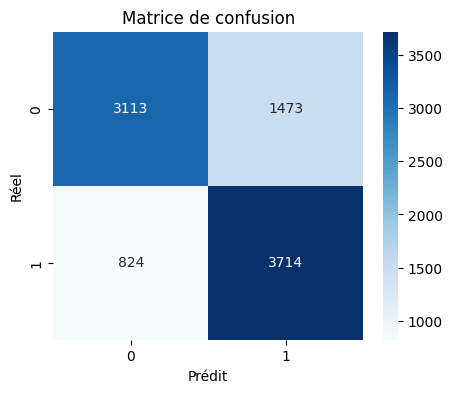

In [17]:
# Matrice de confusion
cm = confusion_matrix(y_test,y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

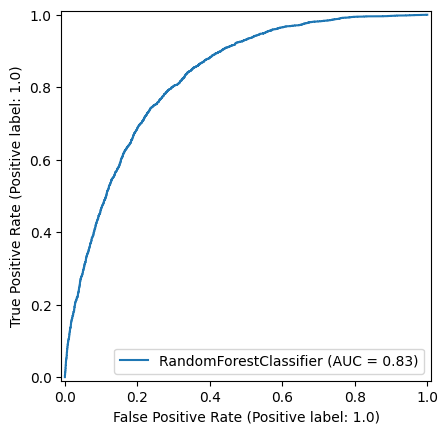

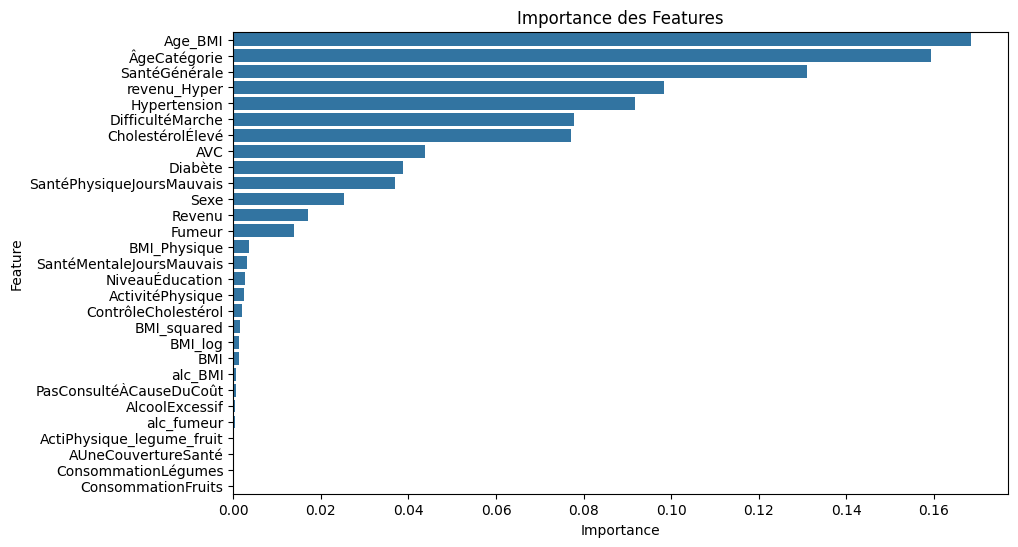

In [18]:
# ROC Curve
RocCurveDisplay.from_estimator(best_model, x_test_selected, y_test)
plt.show()

# Importance des features
feature_importances = pd.DataFrame({
    'Feature': x_train_selected.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title("Importance des Features")
plt.show()


In [19]:
# ============================
# MÉTRIQUES CLÉS
# ============================
specificity = cm[0,0] / (cm[0,0] + cm[0,1])
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_prob)

print("\n=== 🔍 MÉTRIQUES CLÉS ===")
print(f"Accuracy           : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Recall (Sensibilité): {recall_score(y_test, y_test_pred):.4f}")
print(f"Précision          : {precision_score(y_test, y_test_pred):.4f}")
print(f"F1-score           : {f1_score(y_test, y_test_pred):.4f}")
print(f"Spécificité        : {specificity:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")



=== 🔍 MÉTRIQUES CLÉS ===
Accuracy           : 0.7482
Recall (Sensibilité): 0.8184
Précision          : 0.7160
F1-score           : 0.7638
Spécificité        : 0.6788
Balanced Accuracy  : 0.7486
ROC-AUC            : 0.8274


In [20]:
import joblib
joblib.dump(best_model,"best_model_heart_Ameliorer.pkl")

['best_model_heart_Ameliorer.pkl']